In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import numpy as np
import pytz
pd.set_option('display.max_columns', None)

In [2]:
# Cargar el dataset
df = pd.read_csv('../data/raw/trafico_web_sintetico.csv')

# Ver las primeras filas
df.head()

,timestamp,ip_address,user_agent,url_path,http_method,response_code,bytes_sent,referrer,session_id,country_code
0,2025-04-05T03:31:14.948446,89.154.37.5,Mozilla/5.0 (Windows NT 10.0; Win64; x64),/search?q=celular,GET,200,15497,http://roberts.com/,fe6b9eed-a628-4ee7-b0bd-5837fa2c76ae,US
1,2025-04-04T21:00:55.863044,156.7.6.181,Mozilla/5.0 (Linux; Android 11; Pixel 5),/item/67890,GET,200,6329,https://brown-ritter.com/register.htm,5e2dee2a-8537-46af-9ff7-20d66ac3801c,CL
2,2025-04-04T02:42:04.771155,69.156.251.9,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7),/profile,GET,200,12382,http://marquez.com/list/search.html,45de430d-1a89-409e-bb5a-c76d93443c12,AR
3,2025-04-01T09:47:54.905328,59.245.81.214,Mozilla/5.0 (Linux; Android 11; Pixel 5),/home,GET,404,22448,http://www.carr.info/tag/explore/post/,bcbb3355-84d6-4d60-b420-e6565b872950,CL
4,2025-04-02T16:57:34.084610,135.166.97.174,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7),/category/electronics,GET,200,10812,https://www.schmitt.org/homepage.html,0b1b1b3b-8b16-4955-9c59-fdce6bdb243c,CL


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   timestamp      120000 non-null  object
 1   ip_address     120000 non-null  object
 2   user_agent     120000 non-null  object
 3   url_path       120000 non-null  object
 4   http_method    120000 non-null  object
 5   response_code  120000 non-null  int64 
 6   bytes_sent     120000 non-null  int64 
 7   referrer       84000 non-null   object
 8   session_id     120000 non-null  object
 9   country_code   120000 non-null  object
dtypes: int64(2), object(8)
memory usage: 9.2+ MB


- Cantidad de datos: 120,000 solicitudes HTTP (bastante robusto).

- Datos nulos:

    - El campo referrer tiene 28% de valores faltantes (solo 84,000 de 120,000).
    - Los demás campos están completos.

- Tipos de datos:

    - timestamp debería convertirse a formato datetime (ahora es object).

    - response_code y bytes_sent son numéricos (int64). response_code deberia cambiar a categorico

    - El resto son object, aunque algunos (como http_method y country_code) podrían ser categóricos.

In [4]:
# Convertir 'timestamp' a datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce', utc=True)
df['response_code'] = df['response_code'].astype('string')

# Convertir el resto de columnas object a string (excepto las ya transformadas)
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype('string')

df['referrer'] = df['referrer'].fillna('NULO')

In [5]:
df.describe(include='all')

,timestamp,ip_address,user_agent,url_path,http_method,response_code,bytes_sent,referrer,session_id,country_code
count,120000,120000,120000,120000,120000,120000,120000.000000,120000,120000,120000
unique,NaN,84253,10,210,2,4,NaN,71937,119408,6
top,NaN,192.168.0.102,Mozilla/5.0 (Linux; Android 11; Pixel 5),/orders,GET,200,NaN,NULO,bot-session-1558,??
freq,NaN,172,20060,7442,113932,107855,NaN,36000,5,36000
mean,2025-04-02 07:28:30.799636480+00:00,NaN,NaN,NaN,NaN,NaN,5500.136342,NaN,NaN,NaN
min,2025-04-01 00:00:00.457929+00:00,NaN,NaN,NaN,NaN,NaN,500.000000,NaN,NaN,NaN
25%,2025-04-01 03:29:01.918871296+00:00,NaN,NaN,NaN,NaN,NaN,1936.000000,NaN,NaN,NaN
50%,2025-04-01 16:48:38.377122048+00:00,NaN,NaN,NaN,NaN,NaN,3979.000000,NaN,NaN,NaN
75%,2025-04-03 10:19:18.020746240+00:00,NaN,NaN,NaN,NaN,NaN,7423.250000,NaN,NaN,NaN
max,2025-04-05 03:50:35.069982+00:00,NaN,NaN,NaN,NaN,NaN,59206.000000,NaN,NaN,NaN


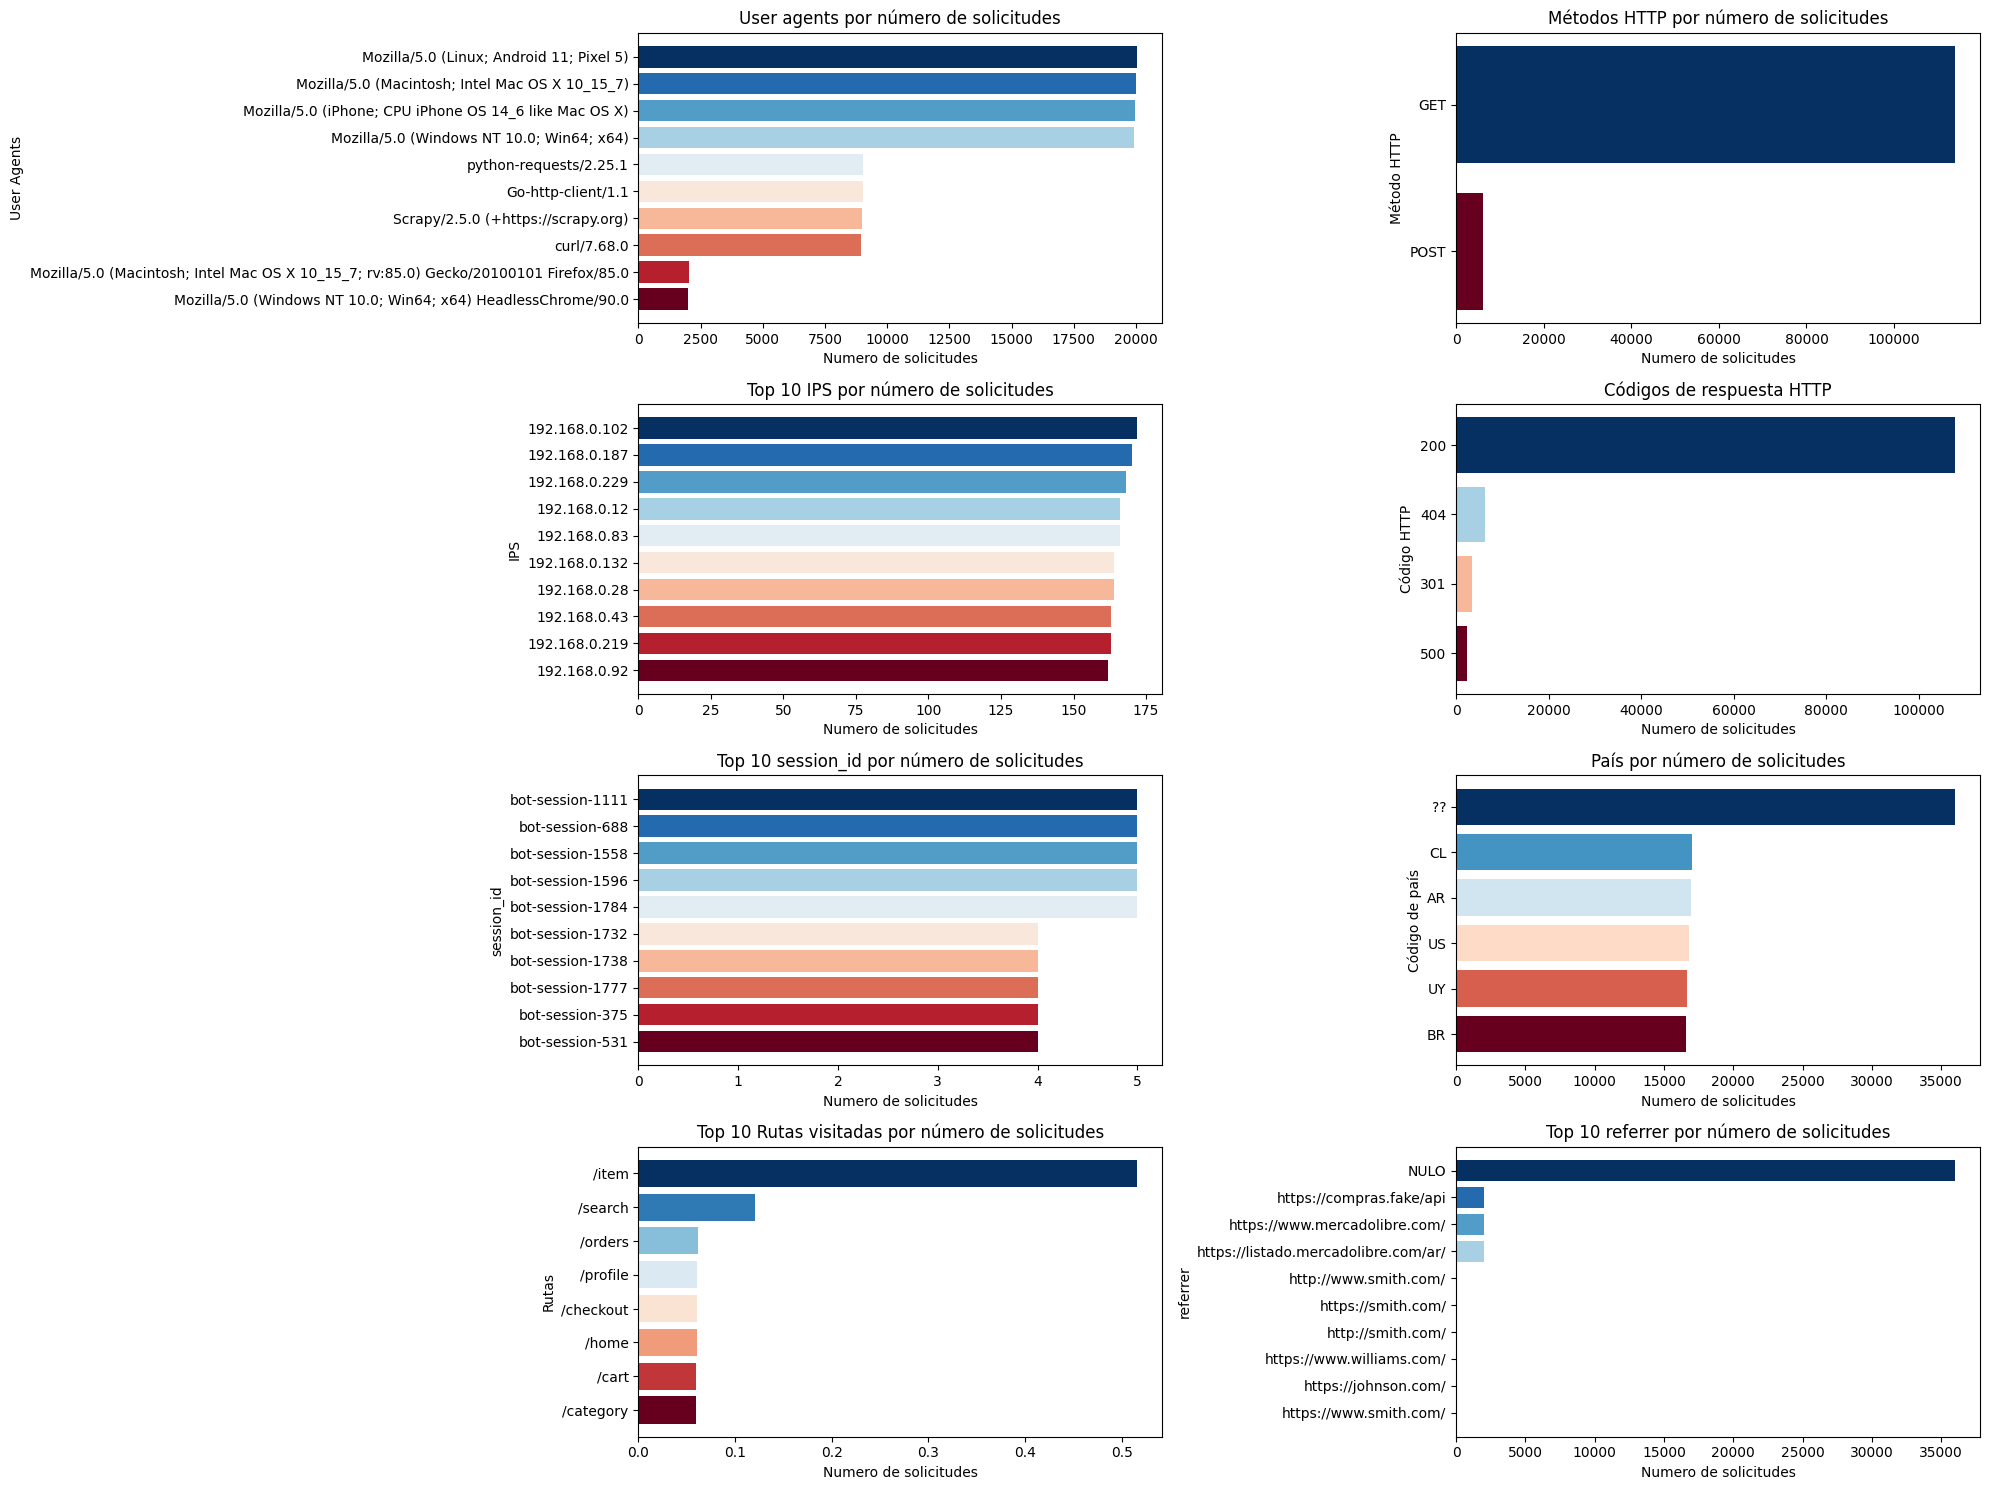

In [6]:
top_agents = df['user_agent'].value_counts().head(10).sort_values()
top_http_methods = df['http_method'].value_counts().head(10).sort_values()
top_ip_address = df['ip_address'].value_counts().head(10).sort_values()
top_response_code = df['response_code'].value_counts().head(10).sort_values()
top_sessions = df['session_id'].value_counts().head(10).sort_values()
top_country_code = df['country_code'].value_counts().head(10).sort_values()
top_url_path = df['url_path'].str.extract(r'^(/[^/?]+)', expand=False).value_counts(normalize=True).head(10).sort_values()
top_referrer = df['referrer'].value_counts().head(10).sort_values()


# Crear figura y ejes
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(20, 15))
axes = axes.flatten()

# Lista de datos y configuraciones
plots = [
    (top_agents, 'User agents por número de solicitudes', 'Numero de solicitudes', 'User Agents'),
    (top_http_methods, 'Métodos HTTP por número de solicitudes', 'Numero de solicitudes', 'Método HTTP'),
    (top_ip_address, 'Top 10 IPS por número de solicitudes', 'Numero de solicitudes', 'IPS'),
    (top_response_code, 'Códigos de respuesta HTTP', 'Numero de solicitudes', 'Código HTTP'),
    (top_sessions, 'Top 10 session_id por número de solicitudes', 'Numero de solicitudes', 'session_id'),
    (top_country_code, 'País por número de solicitudes', 'Numero de solicitudes', 'Código de país'),
    (top_url_path, 'Top 10 Rutas visitadas por número de solicitudes', 'Numero de solicitudes', 'Rutas'),
    (top_referrer, 'Top 10 referrer por número de solicitudes', 'Numero de solicitudes', 'referrer')
]

# Graficar cada uno
for i, (data, title, xlabel, ylabel) in enumerate(plots):
    colors = cm.RdBu(np.linspace(0, 1, len(data)))
    axes[i].barh(data.index, data.values, color=colors)
    axes[i].set_title(title)
    axes[i].set_xlabel(xlabel)
    axes[i].set_ylabel(ylabel)

# Eliminar subplot vacío si es impar
if len(plots) < len(axes):
    fig.delaxes(axes[-1])

# Ajustar diseño
plt.tight_layout()
plt.savefig("../reports/figures/estadistica_basica.jpg")
plt.show()


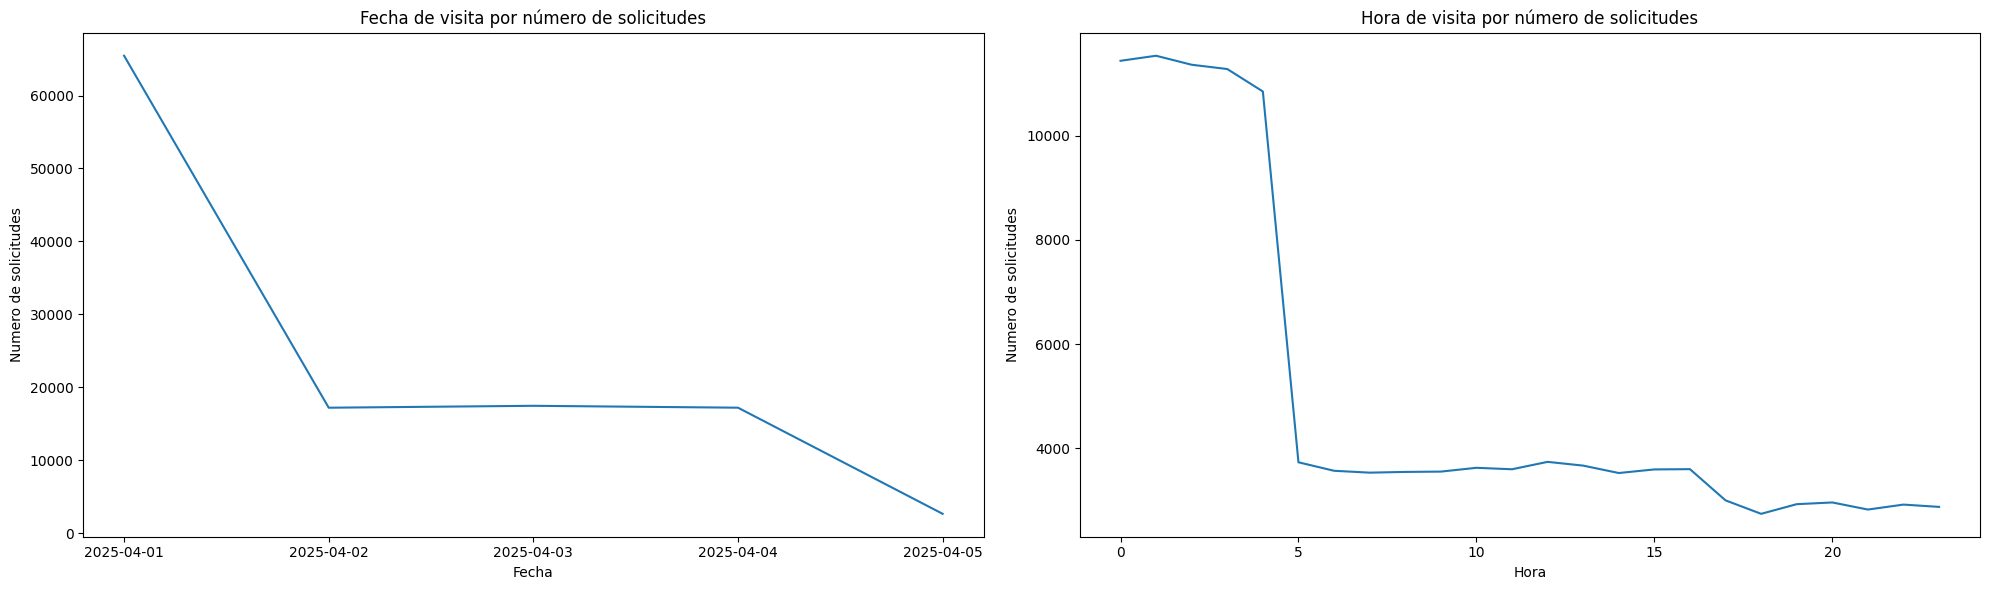

In [7]:
top_timestamp_date = df["timestamp"].dt.date.astype('str').value_counts().sort_index()
top_timestamp_hour = df["timestamp"].dt.hour.value_counts().sort_index(ascending=False)

# Crear figura y ejes
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 6))
axes = axes.flatten()

# Lista de datos y configuraciones
plots = [
    (top_timestamp_date, 'Fecha de visita por número de solicitudes', 'Fecha', 'Numero de solicitudes'),
    (top_timestamp_hour, 'Hora de visita por número de solicitudes', 'Hora', 'Numero de solicitudes'),
]

# Graficar cada uno
for i, (data, title, xlabel, ylabel) in enumerate(plots):
    colors = cm.RdBu(np.linspace(0, 1, len(data)))
    axes[i].plot(data.index, data.values)
    axes[i].set_title(title)
    axes[i].set_xlabel(xlabel)
    axes[i].set_ylabel(ylabel)

# Eliminar subplot vacío si es impar
if len(plots) < len(axes):
    fig.delaxes(axes[-1])

# Ajustar diseño
plt.tight_layout()
plt.show()

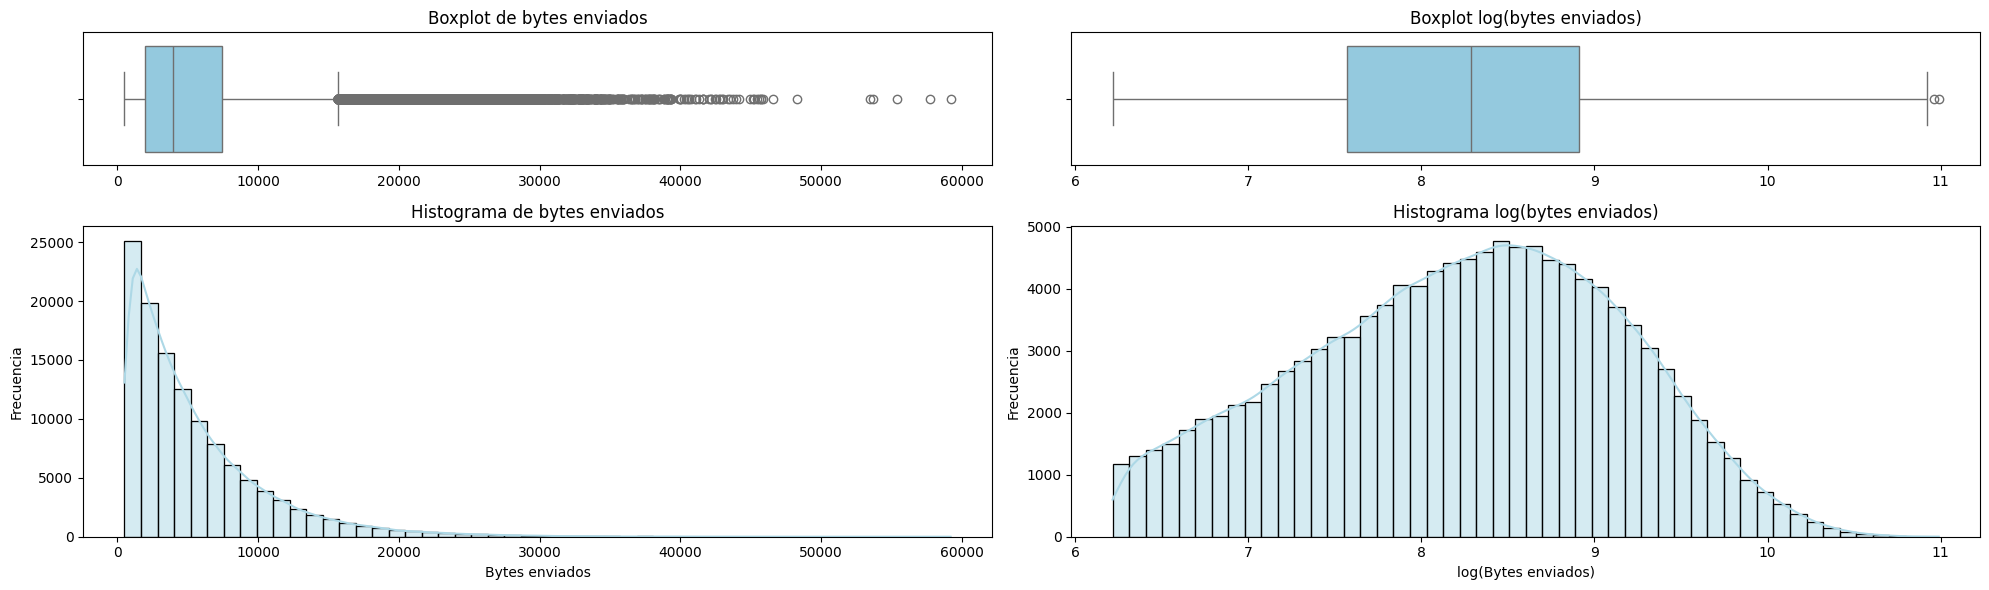

In [8]:
df['log_bytes'] = np.log1p(df['bytes_sent'])

fig, axes = plt.subplots(
    nrows=2, ncols=2,
    figsize=(20,6),
    sharey=False,
    gridspec_kw={"height_ratios": [0.3, 0.7]}
)

# --- Fila 1: Boxplots ---
# Boxplot bytes_sent
sns.boxplot(x=df['bytes_sent'], ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Boxplot de bytes enviados')
axes[0, 0].set_xlabel('')

# Boxplot log_bytes
sns.boxplot(x=df['log_bytes'], ax=axes[0, 1], color='skyblue')
axes[0, 1].set_title('Boxplot log(bytes enviados)')
axes[0, 1].set_xlabel('')

# --- Fila 2: Histogramas ---
# Histograma bytes_sent
sns.histplot(df['bytes_sent'], bins=50, kde=True, ax=axes[1, 0], color='lightblue')
axes[1, 0].set_title('Histograma de bytes enviados')
axes[1, 0].set_xlabel('Bytes enviados')
axes[1, 0].set_ylabel('Frecuencia')

# Histograma log_bytes
sns.histplot(df['log_bytes'], bins=50, kde=True, ax=axes[1, 1], color='lightblue')
axes[1, 1].set_title('Histograma log(bytes enviados)')
axes[1, 1].set_xlabel('log(Bytes enviados)')
axes[1, 1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()


- Timestamp:
    - Las solicitudes tienen un rango del 2025-04-01 al 2025-04-05.

- IP address:
    - Hay 84,253 IPs únicas en 120,000 registros (~70%).
    - Hay IPs repetidas (la IP más repetida aparece 172 veces).

- User-Agent:
    - Solo 10 User-Agents distintos.

- URL Path:
    - Es probable que /item esté siendo objetivo principal de scrapers, tratando de obtener información de productos masivamente.

- HTTP Method:
    - Solo 2 tipos de métodos: GET y POST.
    - Casi todo el tráfico es GET ~95%.

- Response code:
    - Solo 4 tipos de codigos
    - Casi todo el tráfico es 200 (OK) ~90%.

- Bytes enviados:
    - Datos concentrados en valores pequeños.
    - Valores extremadamente altos que son outliers

- Distribucion log Bytes:
    - La mayoría de los datos caen entre log_bytes 7.5 y 8.9, es decir, entre 1KB y 13KB
    - Caída rápida en valores altos desde 8.9

- Referrer:
    - 28% faltante.
    - El más común es https://compras.fake/api (2,017 veces).

- Session ID:
    - Casi todos son únicos (99%).
    - Algunos session_id parecen de bots (bot-session-1784).

- Country Code:
    - Solo 6 códigos de país distintos.
    - ?? es el más frecuente (36,000 veces), probablemente tráfico anónimo.

### Ideas e hipotesis

| **Campo**       | **Normal en humanos** | **Sospechoso en bots o anomalías** | **Precauciones clave** | **Cómo detectar** |
|-----------------|------------------------|-------------------------------------|--------------------------|--------------------|
| `timestamp`     | horarios de visitas durante el dia | horarios de visitas en la madrugada | las visitas en la madrugada no son tan comunes | Calcular si hubo visitas nocturnas por IP |
| `ip_address`    | Muchas IPs con baja frecuencia | IPs con alto número de solicitudes | Muchas solicitudes desde una IP puede indicar scraping | Contar requests por IP y marcar las que están por encima del percentil 95-99 de frecuencia. |
| `user_agent`    | Navegadores comunes (Chrome, Mozilla, etc.) | `curl`, `Scrapy`, `python-requests` o valores raros y repetidos | Los bots pueden falsificar user-agent para parecer tráfico legítimo. | Identificar user-agents sospechosos y verificar diversidad por IP |
| `url_path`      | Navegación variada | Frecuencia alta en rutas | Accesos repetidos a rutas sugiere scraping dirigido | Ver rutas más frecuentes por IP |
| `http_method`   | Uso mayoritario de `GET`, algunos `POST` | Repetitivo uso de `POST` | Métodos inusuales pueden ser indicio de testing malicioso o scraping avanzado | Revisar metodos inusuales por `url_path` |
| `response_code` | Mayoría `200`, pocos errores (`404`, `403`) | Alto porcentaje de errores desde una IP | Muchas respuestas de error podrían indicar escaneo o scraping fallido | Revisar errores por IP (especialmente 404 y 403) |
| `bytes_sent`    | Varía según recurso (páginas, imágenes, etc.) | Muy bajo o constante (ej. 500 bytes) | Variabilidad es normal, constancia sugiere tráfico no real | Analizar desviación estándar de `bytes_sent` por IP; baja variabilidad es sospechosa. |
| `referrer`      | Presente y coherente (misma sesión) | Vacío o referrers inconsistentes | Bots usualmente no envían referrer o lo falsifican con valores no válidos. | Calcular % sin referrer por IP y ver si se concentra en ciertos patrones |
| `session_id`    | Reutilizado durante la sesión | Uno diferente por request o patrones tipo `bot-session-*` | Valores autogenerados o únicos por request pueden indicar bots | Detectar exceso de `session_id` únicos por IP y patrones en su nomenclatura (`regex`). |
| `country_code`  | Códigos coherentes con tu mercado objetivo | `??` o países atípicos | Algunos servicios de VPN/anonymizer ocultan país de origen; `??` es una señal. | Filtrar por país, marcar IPs con código `??` o regiones atípicas según distribución general. |


# Limpieza y Creacion de Caracteristicas

In [9]:
def clasificar_referrer(ref):
    if ref == 'NULO':
        return 'NULO'
    elif 'mercadolibre' in ref:
        return 'INTERNO'
    elif 'api' in ref.strip().lower():
        return 'API'
    else:
        return 'OTRO'

df['referrer_type'] = df['referrer'].apply(clasificar_referrer)

df = pd.concat([df.reset_index().drop(columns='index'), pd.get_dummies(df['referrer_type'], prefix='referrer_type').reset_index().drop(columns='index')], axis=1)

df['standar_url_path'] = df['url_path'].str.extract(r'^(/[^/?]+)', expand=False)

# Detección de session_id tipo bot
df['is_bot_session'] = df['session_id'].str.contains(r'bot-session-\d+', na=False)

# Códigos de país anómalos
df['is_country_unknown'] = df['country_code'] == '??'

# métodos HTTP
# captura el uso anómalo de métodos HTTP, como POST en rutas que normalmente son GET.
df['suspicious_post_usage'] = (
    (df['http_method'] == 'POST') &
    (df['standar_url_path'].isin(['/item', '/search', '/home', '/category', '/profile', '/checkout']))
)

# captura frecuencia sospechosa en ruta /item
df['suspicious_high_freq_path'] = df['standar_url_path'].isin(['/item'])

# Detección de user_agent sospechoso
suspicious_agents = ['python-requests', 'curl', 'Scrapy', 'go-http-client']
df['is_suspicious_ua'] = df['user_agent'].str.contains('|'.join(suspicious_agents), case=False, na=False)

# tiempo entre solicitudes consecutivas
df = df.sort_values(by=['session_id', 'timestamp'])
df['delta_seconds'] = df.groupby('session_id')['timestamp'].diff().dt.total_seconds()

# Frecuencia de errores HTTP por fila
df['is_not_found_error'] = df['response_code'].isin(['404'])

In [10]:
# Algunas características útiles por ip_address

# 1. Frecuencia, ritmo de visitas y tamaño de bytes
ip_features = df.groupby('ip_address').agg(
    total_requests=('timestamp', 'count'),
    std_byte_size=('bytes_sent', 'std')
)

ip_features['std_byte_size'] = ip_features['std_byte_size'].fillna(0)

# Calcular percentiles
p95 = ip_features['total_requests'].quantile(0.95)
# Marcar IPs por encima de esos umbrales
ip_features['total_requests_above_p95'] = ip_features['total_requests'] > p95

# 3. Tasa de errores
ip_features['had_error'] = df.groupby('ip_address')['is_not_found_error'].max()

# 4. Proporción de agentes sospechosos, referrers internos, etc.
ip_features['had_suspicious_ua'] = df.groupby('ip_address')['is_suspicious_ua'].max()
ip_features['had_referrer_type_interno'] = df.groupby('ip_address')['referrer_type_INTERNO'].max()
ip_features['had_referrer_type_api'] = df.groupby('ip_address')['referrer_type_API'].max()
ip_features['had_referrer_type_nulo'] = df.groupby('ip_address')['referrer_type_NULO'].max()
ip_features['had_bot_sessions'] = df.groupby('ip_address')['is_bot_session'].max()
ip_features['had_unknown_country'] = df.groupby('ip_address')['is_country_unknown'].max()
ip_features['had_suspicious_post_usage'] = df.groupby('ip_address')['suspicious_post_usage'].max()
ip_features['had_suspicious_high_freq_path'] = df.groupby('ip_address')['suspicious_high_freq_path'].max()


# 5. Horarios de actividad (porcentaje en madrugada)
ip_features['night_activity_rate'] = (
    df[(df['timestamp'].dt.hour >= 0) & (df['timestamp'].dt.hour < 5)]
    .groupby('ip_address')
    .size() / df.groupby('ip_address').size()
).fillna(0)

In [13]:
ip_features.describe(include='all')

,total_requests,std_byte_size,total_requests_above_p95,had_error,had_suspicious_ua,had_referrer_type_interno,had_referrer_type_api,had_referrer_type_nulo,had_bot_sessions,had_unknown_country,had_suspicious_post_usage,had_suspicious_high_freq_path,night_activity_rate
count,84253.000000,84253.000000,84253,84253,84253,84253,84253,84253,84253,84253,84253,84253,84253.000000
unique,NaN,NaN,2,2,2,2,2,2,2,2,2,2,NaN
top,NaN,NaN,False,False,False,False,False,False,False,False,False,False,NaN
freq,NaN,NaN,84000,79538,84000,80264,82199,84000,84001,84000,80546,58046,NaN
mean,1.424282,14.979315,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.246809
std,7.756266,274.747132,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.431149
min,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
25%,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
50%,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
75%,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000


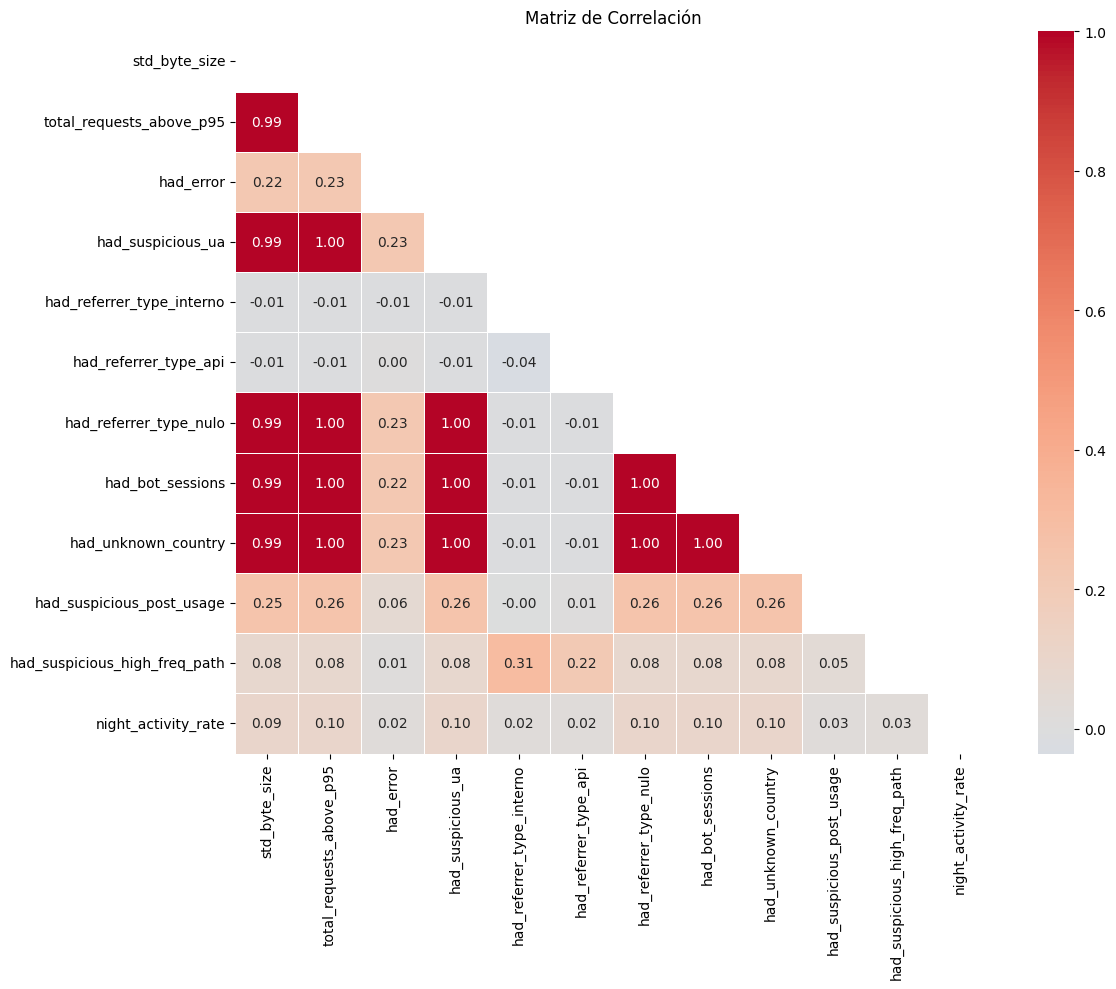

In [11]:
corr_matrix = ip_features.drop(columns='total_requests').corr(numeric_only=True)

# Crear el heatmap
corr = ip_features.drop(columns='total_requests').corr(numeric_only=True)

# Crear máscara para ocultar la parte superior del triángulo
mask = np.triu(np.ones_like(corr, dtype=bool))

# Dibujar el heatmap con máscara
plt.figure(figsize=(12, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Matriz de Correlación")
plt.tight_layout()
plt.show()

In [12]:
ip_features.drop(columns='total_requests').to_csv('../data/processed/processed.csv', index=False)